## PIPELINE

In [143]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, 
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# PanelSplit
from panelsplit.cross_validation import PanelSplit
from panelsplit.plot import plot_splits
from panelsplit.application import cross_val_fit_predict

### 1. LOAD DATA AND PREPROCESS 

#### EPIDEMIES DATA

This is the core dataset to construct our target variable. It contains all the information related to epidemics from 2000 to 2025.

In [144]:
# Load the data
df_target = pd.read_excel('data/emdat_target_variable.xlsx')

print(df_target.columns)
df_target.head()

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update'],
      dtype='str')


,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,Subregion,Region,Location,Origin,Associated Types,OFDA/BHA Response,Appeal,Declaration,AID Contribution ('000 US$),Magnitude,Magnitude Scale,Latitude,Longitude,River Basin,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2001-0551-MOZ,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,Cholera,MOZ,Mozambique,Sub-Saharan Africa,Africa,Mocuba district (Zambezia province),NaN,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,2001,8.0,NaN,2001,8.0,NaN,7.0,NaN,611.0,NaN,611.0,NaN,NaN,NaN,NaN,NaN,NaN,54.999385,NaN,NaN,2003-07-01,2023-09-25
1,2006-0726-PRK,No,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,NaN,PRK,Democratic People's Republic of Korea,Eastern Asia,Asia,"Kimhyongjik county (Ryanggang province), natio...",NaN,NaN,No,No,No,NaN,NaN,Vaccinated,NaN,NaN,NaN,2006,11.0,NaN,2007,2.0,NaN,4.0,NaN,3000.0,NaN,3000.0,NaN,NaN,NaN,NaN,NaN,NaN,62.617195,NaN,NaN,2007-03-28,2023-09-25
2,2000-0460-THA,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,NaN,NaN,THA,Thailand,South-eastern Asia,Asia,"Northern, North-eastern regions",NaN,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,2000,1.0,NaN,2000,1.0,NaN,89.0,NaN,1946.0,NaN,1946.0,NaN,NaN,NaN,NaN,NaN,NaN,53.487737,NaN,NaN,2003-07-01,2023-09-25
3,2022-0643-HTI,No,nat-bio-epi-bac,Natural,Biological,Epidemic,Bacterial disease,GLIDE:EP-2022-000325,Cholera,HTI,Haiti,Latin America and the Caribbean,Americas,Port-au-Prince; Centre Department (Mirebalais),NaN,NaN,No,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,2022,10.0,1.0,2022,11.0,30.0,511.0,960.0,1938.0,NaN,2898.0,NaN,NaN,NaN,NaN,NaN,NaN,90.902697,NaN,NaN,2022-10-10,2023-09-26
4,2022-0652-UGA,No,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,GLIDE:EP-2022-000315,Ebola,UGA,Uganda,Sub-Saharan Africa,Africa,"Mubende, Kyegegwa, Kassanda, Kagadi, Bunyangab...",NaN,NaN,No,No,Yes,NaN,NaN,Vaccinated,NaN,NaN,NaN,2022,9.0,20.0,2023,1.0,11.0,55.0,142.0,NaN,NaN,142.0,NaN,NaN,NaN,NaN,NaN,NaN,90.902697,NaN,NaN,2022-10-11,2023-09-26


In [145]:
df_target["Disaster Type"].value_counts()

Disaster Type
Epidemic       893
Infestation     29
Name: count, dtype: int64

We only want to keep the ones where `Disaster Type` == Epidemic, as we are trying to predict a new epidemy.

In [146]:
df_target = df_target[df_target["Disaster Type"]=="Epidemic"]

Now we are interested in agregating the data by country and month. To characterize the country we are going to use the ISO code.

In [147]:
df_target["Start Month"].head()

0     8.0
1    11.0
2     1.0
3    10.0
4     9.0
Name: Start Month, dtype: float64

In [148]:
df_target["Start Year"].head()

0    2001
1    2006
2    2000
3    2022
4    2022
Name: Start Year, dtype: int64

We need to creat the vaariable `month` from the two columns `Start Month` and `Start Year`. First we are dropping all the rows that doesen't have the `Start Month` or `Start Year`, because those are the main things that we need to have.

In [149]:
nan_summary = df_target[['Start Month', 'Start Year']].isna().sum()

print("Total Missing Values per Column:")
print(nan_summary)

Total Missing Values per Column:
Start Month    24
Start Year      0
dtype: int64


In [150]:
df_target = df_target.dropna(subset=['Start Month', 'Start Year'])

Now let's create the month variable:

In [151]:
df_target['month'] = pd.to_datetime({
    'year': df_target['Start Year'],
    'month': df_target['Start Month'],
    'day': 1
})

# Verify the result
print(df_target[['Start Year', 'Start Month', 'month']].head())

   Start Year  Start Month      month
0        2001          8.0 2001-08-01
1        2006         11.0 2006-11-01
2        2000          1.0 2000-01-01
3        2022         10.0 2022-10-01
4        2022          9.0 2022-09-01


In [152]:
print("Oldest date:", df_target['month'].min())
print("Latest date:", df_target['month'].max())

Oldest date: 2000-01-01 00:00:00
Latest date: 2025-12-01 00:00:00


The last thing that we have to do is check that there are no missing values in `ISO` column, as is the other one that we are going to use to aggregate the data.

In [153]:
print(df_target['ISO'].isna().sum())

0


Finally we set the multi-index (Entity (`ISO`) and Time (`month`)):

In [154]:
df_target = df_target.set_index(['ISO', 'month']).sort_index()

In order to facilitate the study, we are going to create a dataset only containing the presence or absence of epidemics. This new DataFrame expands our data into a balanced panel where every country (ISO) is mapped against every available time period (month). The final dataset uses a MultiIndex ['ISO', 'month'] and a single binary column, epidemy, where a 1 indicates an active epidemic outbreak and a 0 indicates no recorded activity for that specific country and period.

In [155]:
df_target['epidemy'] = 1

# Collapse duplicates in the index by keeping the maximum (1)
df_collapsed = df_target.groupby(['ISO', 'month'])[['epidemy']].max()

# Generate all possible combinations of ISO and month (MultiIndex)
all_isos = df_collapsed.index.get_level_values('ISO').unique()
all_months = df_collapsed.index.get_level_values('month').unique()
full_index = pd.MultiIndex.from_product([all_isos, all_months], names=['ISO', 'month'])

epidemy = df_collapsed.reindex(full_index, fill_value=0).sort_index()

print(epidemy.head(20))
print("\nValue counts:")
print(epidemy['epidemy'].value_counts())

                epidemy
ISO month              
AFG 2000-01-01        1
    2000-02-01        0
    2000-03-01        0
    2000-04-01        0
    2000-05-01        1
    2000-06-01        0
    2000-07-01        0
    2000-08-01        1
    2000-09-01        1
    2000-10-01        0
    2000-11-01        0
    2000-12-01        0
    2001-01-01        0
    2001-02-01        0
    2001-03-01        0
    2001-04-01        0
    2001-05-01        0
    2001-06-01        1
    2001-07-01        0
    2001-08-01        0

Value counts:
epidemy
0    31027
1      806
Name: count, dtype: int64


In [156]:
epidemy.to_csv("data/epidemy.csv", index=True)

#### FEATURE VARAIBLES

The second dataset that we need is one containing all the variables assocciated with health that will help us predict an epidemology. In this case we are using data from Health World Bank, divided in 8 files containing information from 1960 to 2024. 

In [157]:
folder_path = 'data/health_world_bank/'
files = []

# Find all CSV files inside the data folder
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        files.append(filename)

# Process and merge the datasets
for idx, file in enumerate(files):
    df = pd.read_csv(os.path.join(folder_path, file))
    df = df.dropna(subset=['Country Code'])
    df = df.set_index(['Series Name', 'Country Code'])
    df = df.drop(['Series Code', 'Country Name'], axis=1)
    
    if idx == 0:
        regressors = df.copy()
    else:
        regressors = regressors.join(df)

print(f"Total files processed: {len(files)}")
regressors

Total files processed: 8


1960 [YR1960]  \
Series Name                                        Country Code                 
Cause of death, by communicable diseases and ma... AFG                     ..   
                                                   AFE                     ..   
                                                   AFW                     ..   
                                                   ALB                     ..   
                                                   DZA                     ..   
...                                                                       ...   
Specialist surgical workforce (per 100,000 popu... PSE                     ..   
                                                   WLD                     ..   
                                                   YEM                     ..   
                                                   ZMB                     ..   
                                                   ZWE                     ..   

                                                                1961 [YR1961]  \
Series Name                                        Country Code                 
Cause of death, by communicable diseases and ma... AFG                     ..   
                                                   AFE                     ..   
                                                   AFW                     ..   
                                                   ALB                     ..   
                                                   DZA                     ..   
...                                                                       ...   
Specialist surgical workforce (per 100,000 popu... PSE                     ..   
                                                   WLD                     ..   
                                                   YEM                     ..   
                                                   ZMB                     ..   
                                                   ZWE                     ..   

                                                                1962 [YR1962]  \
Series Name                                        Country Code                 
Cause of death, by communicable diseases and ma... AFG                     ..   
                                                   AFE                     ..   
                                                   AFW                     ..   
                                                   ALB                     ..   
                                                   DZA                     ..   
...                                                                       ...   
Specialist surgical workforce (per 100,000 popu... PSE                     ..   
                                                   WLD                     ..   
                                                   YEM                     ..   
                                                   ZMB                     ..   
                                                   ZWE                     ..   

                                                                1963 [YR1963]  \
Series Name                                        Country Code                 
Cause of death, by communicable diseases and ma... AFG                     ..   
                                                   AFE                     ..   
                                                   AFW                     ..   
                                                   ALB                     ..   
                                                   DZA                     ..   
...                                                                       ...   
Specialist surgical workforce (per 100,000 popu... PSE                     ..   
                                                   WLD                     ..   
                                                   YEM                     ..   
           

As we can see, this data comes in a weird format, so we are going to preprocess it to obtain the desired format: each row should be a country x month, and all the series should be columns.

In [158]:
regressors.columns = regressors.columns.str.extract(r'(\d{4})', expand=False)
regressors.columns.name = 'Year'

reg_final = (regressors
             .stack()
             .unstack('Series Name')
             .reset_index()
            )

reg_final.columns.name = None

reg_final.sample(10)

,Country Code,Year,ARI treatment (% of children under 5 taken to a health provider),Capital health expenditure (% of GDP),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)","Cause of death, by injury (% of total)","Cause of death, by non-communicable diseases (% of total)","Cause of death, by other COVID-19 pandemic-related outcomes (% of total)",Children with fever receiving antimalarial drugs (% of children under age 5 with fever),"Community health workers (per 1,000 people)",Current health expenditure (% of GDP),Current health expenditure per capita (current US$),"Current health expenditure per capita, PPP (current international $)",Diarrhea treatment (% of children under 5 receiving oral rehydration and continued feeding),Diarrhea treatment (% of children under 5 who received ORS packet),Domestic general government health expenditure (% of GDP),Domestic general government health expenditure (% of current health expenditure),Domestic general government health expenditure (% of general government expenditure),Domestic general government health expenditure per capita (current US$),"Domestic general government health expenditure per capita, PPP (current international $)",Domestic private health expenditure (% of current health expenditure),Domestic private health expenditure per capita (current US$),"Domestic private health expenditure per capita, PPP (current international $)",External health expenditure (% of current health expenditure),External health expenditure channeled through government (% of external health expenditure),External health expenditure per capita (current US$),"External health expenditure per capita, PPP (current international $)","Hospital beds (per 1,000 people)","Immunization, BCG (% of one-year-old children)","Immunization, DPT (% of children ages 12-23 months)","Immunization, HepB3 (% of one-year-old children)","Immunization, Hib3 (% of children ages 12-23 months)","Immunization, Pol3 (% of one-year-old children)","Immunization, measles (% of children ages 12-23 months)","Immunization, measles second dose (% of children by the nationally recommended age)","Incidence of malaria (per 1,000 population at risk)","Incidence of tuberculosis (per 100,000 people)",Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),Malaria cases reported,"Mortality caused by road traffic injury (per 100,000 people)","Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%)","Mortality rate attributed to household and ambient air pollution (per 100,000 population)","Mortality rate attributed to unintentional poisoning (per 100,000 population)","Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (per 100,000 population)",Number of people pushed or further pushed below the $2.15 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure,Number of people pushed or further pushed below the 60% median consumption poverty line by out-of-pocket health care expenditure,Number of people spending more than 10% of household consumption or income on out-of-pocket health care expenditure,Number of people spending more than 25% of household consumption or income on out-of-pocket health care expenditure,"Number of surgical procedures (per 100,000 population)","Nurses and midwives (per 1,000 people)","People practicing open defecation, urban (% of urban population)",People using at least basic drinking water services (% of population),People using at least basic sanitation services (% of population),People using safely managed drinking water services (% of population),People using safely managed sanitation services (% of population),"People using safely managed sanitation services, rural (% of rural population)","People using safely managed sanitation services, urban (% of urban population)",People with basic handwashing facilities including soap and water (% of population),"People with basic handwas

To handle missing values without distorting country profiles, we group the data by country and propagate the last available historical value forward (and backward) in time. Any remaining columns with absolutely no historical data for a specific country are safely filled using the global column median.

Note that we can't do Backward Fill because that will introduce data leakage (seeing data from the futur in the present).

First note that in this dataset Nan are introduced as `..`, so the first thing is replace these fore real NaN.

In [159]:
# Replace '..' with actual NaN values 
reg_monthly = reg_final.replace('..', np.nan)

for col in reg_monthly.columns:
    if col not in ['Country Code', 'Year']:
        reg_monthly[col] = pd.to_numeric(reg_monthly[col], errors='coerce')

# Forward-fill within each country to maintain trends, but only for numeric columns
cols_numericas = reg_monthly.select_dtypes(include=[np.number]).columns
cols_to_trend = cols_numericas.drop(['Year'], errors='ignore')
reg_monthly[cols_to_trend] = reg_monthly.groupby('Country Code')[cols_to_trend].ffill()

# Put the median as a last resort for any remaining NaNs that couldn't be filled by trends
reg_monthly[cols_to_trend] = reg_monthly[cols_to_trend].fillna(reg_monthly[cols_to_trend].median())

Next we have to face another problem, that is that we want the data agreggated by month, but we have it by year in the regressors. That's what we are going to face now.

To strictly avoid data leakage, all annual indicators and their corresponding yearly trends are shifted one year forward for each country before generating the monthly data. As a result, the monthly values for a given year are constructed exclusively using information that would have been available at the beginning of that year.

The interpolation process starts from the previous year’s observed annual value and progressively applies a monthly trend derived from historical year-over-year changes. This creates a smooth intra-year evolution while ensuring that no future annual statistics are used during feature generation. Although this approach introduces a discontinuous adjustment at the transition between years, it is considered appropriate because these macroeconomic and structural indicators tend to evolve gradually and remain relatively stable over time. Most importantly, this design mathematically guarantees a leakage-free temporal construction of the regressors.

In [160]:
# Ensure that the Year column is stored as an integer and sort the dataframe
reg_monthly['Year'] = reg_monthly['Year'].astype(int)
reg_monthly = reg_monthly.sort_values(['Country Code', 'Year'])

# Compute the year-over-year variation for each indicator separately by country
group_diff = reg_monthly.groupby('Country Code')[cols_to_trend].diff().fillna(0)

# Convert the yearly variation into an approximate monthly trend by distributing the annual change uniformly across 12 months
trends_df = (group_diff / 12).rename(columns=lambda x: x + '_trend')

# Combine the original annual indicators with their corresponding monthly trend estimates
reg_annual_combined = pd.concat([reg_monthly, trends_df], axis=1)


# To ensure that no future information is used, we shift both: the annual indicator values and their estimated trends one year forward for each country.
cols_to_shift = list(cols_to_trend) + [c for c in reg_annual_combined.columns if c.endswith('_trend')]
reg_annual_combined[cols_to_shift] = reg_annual_combined.groupby('Country Code')[cols_to_shift].shift(1)
reg_annual_combined = reg_annual_combined.fillna(0)


# Generate all possible combinations of country, year and month and merge the annual information
all_countries = reg_annual_combined['Country Code'].unique()
all_years = reg_annual_combined['Year'].unique()
all_months = range(1, 13)

skeleton = pd.MultiIndex.from_product(
    [all_countries, all_years, all_months],
    names=['Country Code', 'Year', 'month']
).to_frame().reset_index(drop=True)

reg_monthly = pd.merge(skeleton, reg_annual_combined, on=['Country Code', 'Year'], how='left')

# Apply the monthly interpolation
# For each indicator: monthly_value = shifted_annual_value + (monthly_trend * months_elapsed)
for col in cols_to_trend:
    reg_monthly[col] = reg_monthly[col] + (reg_monthly[col + '_trend'] * (reg_monthly['month'] - 1))

# Remove the auxiliary trend columns since they are no longer needed
trend_cols = [c for c in reg_monthly.columns if c.endswith('_trend')]
reg_monthly = reg_monthly.drop(columns=trend_cols)

Finally putting the same format as the epidemics dataframe.

In [161]:
# Create the month column as a datetime object representing the first day of each month. 
# Also we delete the Year column and rename 'Country Code' to 'ISO' for consistency with the target variable.
date_string = reg_monthly['Year'].astype(str) + '-' + reg_monthly['month'].astype(str) + '-01'
reg_monthly['month'] = pd.to_datetime(date_string)
reg_monthly = reg_monthly.drop(columns=['Year']).rename(columns={'Country Code': 'ISO'})

regressors = reg_monthly.set_index(['ISO', 'month']).sort_index()

In [162]:
regressors.sample(20)

,,ARI treatment (% of children under 5 taken to a health provider),Capital health expenditure (% of GDP),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)","Cause of death, by injury (% of total)","Cause of death, by non-communicable diseases (% of total)","Cause of death, by other COVID-19 pandemic-related outcomes (% of total)",Children with fever receiving antimalarial drugs (% of children under age 5 with fever),"Community health workers (per 1,000 people)",Current health expenditure (% of GDP),Current health expenditure per capita (current US$),"Current health expenditure per capita, PPP (current international $)",Diarrhea treatment (% of children under 5 receiving oral rehydration and continued feeding),Diarrhea treatment (% of children under 5 who received ORS packet),Domestic general government health expenditure (% of GDP),Domestic general government health expenditure (% of current health expenditure),Domestic general government health expenditure (% of general government expenditure),Domestic general government health expenditure per capita (current US$),"Domestic general government health expenditure per capita, PPP (current international $)",Domestic private health expenditure (% of current health expenditure),Domestic private health expenditure per capita (current US$),"Domestic private health expenditure per capita, PPP (current international $)",External health expenditure (% of current health expenditure),External health expenditure channeled through government (% of external health expenditure),External health expenditure per capita (current US$),"External health expenditure per capita, PPP (current international $)","Hospital beds (per 1,000 people)","Immunization, BCG (% of one-year-old children)","Immunization, DPT (% of children ages 12-23 months)","Immunization, HepB3 (% of one-year-old children)","Immunization, Hib3 (% of children ages 12-23 months)","Immunization, Pol3 (% of one-year-old children)","Immunization, measles (% of children ages 12-23 months)","Immunization, measles second dose (% of children by the nationally recommended age)","Incidence of malaria (per 1,000 population at risk)","Incidence of tuberculosis (per 100,000 people)",Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),Malaria cases reported,"Mortality caused by road traffic injury (per 100,000 people)","Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%)","Mortality rate attributed to household and ambient air pollution (per 100,000 population)","Mortality rate attributed to unintentional poisoning (per 100,000 population)","Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (per 100,000 population)",Number of people pushed or further pushed below the $2.15 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure,Number of people pushed or further pushed below the 60% median consumption poverty line by out-of-pocket health care expenditure,Number of people spending more than 10% of household consumption or income on out-of-pocket health care expenditure,Number of people spending more than 25% of household consumption or income on out-of-pocket health care expenditure,"Number of surgical procedures (per 100,000 population)","Nurses and midwives (per 1,000 people)","People practicing open defecation, urban (% of urban population)",People using at least basic drinking water services (% of population),People using at least basic sanitation services (% of population),People using safely managed drinking water services (% of population),People using safely managed sanitation services (% of population),"People using safely managed sanitation services, rural (% of rural population)","People using safely managed sanitation services, urban (% of urban population)",People with basic handwashing facilities including soap and water (% of population),"People with basic handwashing facilities i

In [163]:
pd.set_option('display.max_columns', None)
print(regressors.columns)

Index(['ARI treatment (% of children under 5 taken to a health provider)',
       'Capital health expenditure (% of GDP)',
       'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)',
       'Cause of death, by injury (% of total)',
       'Cause of death, by non-communicable diseases (% of total)',
       'Cause of death, by other COVID-19 pandemic-related outcomes (% of total)',
       'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)',
       'Community health workers (per 1,000 people)',
       'Current health expenditure (% of GDP)',
       'Current health expenditure per capita (current US$)',
       'Current health expenditure per capita, PPP (current international $)',
       'Diarrhea treatment (% of children under 5 receiving oral rehydration and continued feeding)',
       'Diarrhea treatment (% of children under 5 who received ORS packet)',
       'Domestic general government health ex

In [164]:
regressors.to_csv("data/regressors.csv", index=True)

#### TEXT DATA

The last dataset that we need to introduce is the one containing data from text. It comes from an LDA in which the first topic (stock_topic_1) corresponds to Health and Education, and we have the data for all country x months from 2010 to 2024.

In [165]:
text = pd.read_csv("data/topics.csv", index_col = 0)
text.head()

,isocode,period,stock_topic_0,stock_topic_1,stock_topic_2,stock_topic_3,stock_topic_4,stock_topic_5,stock_topic_6,stock_topic_7,stock_topic_8,stock_topic_9,stock_topic_10,stock_topic_11,stock_topic_12,stock_topic_13,stock_topic_14,tokens,stock_tokens
0,AFG,201001,0.015494,0.028133,0.149828,0.045481,0.070855,0.020226,0.175732,0.052580,0.019800,0.004761,0.022914,0.036579,0.088708,0.060646,0.208263,46266.0,223668.448646
1,AFG,201002,0.015619,0.028952,0.158657,0.041378,0.070569,0.020737,0.164617,0.049715,0.021267,0.004845,0.021915,0.038197,0.093011,0.061759,0.208764,45909.0,224843.758917
2,AFG,201003,0.014970,0.029925,0.153758,0.038190,0.064274,0.021417,0.156693,0.051960,0.025952,0.004937,0.021165,0.039799,0.093782,0.066846,0.216333,43505.0,223380.007134
3,AFG,201004,0.015099,0.031810,0.159417,0.037715,0.063352,0.021735,0.153907,0.052503,0.025788,0.004879,0.021542,0.040595,0.094116,0.066496,0.211046,26844.0,205548.005707
4,AFG,201005,0.014908,0.034902,0.165338,0.034451,0.062574,0.022844,0.148960,0.051360,0.025376,0.004617,0.022203,0.040729,0.098276,0.067144,0.206317,29560.0,193998.404565


As we said the only interessting column here regarding our study is stock_topic_1, so we are going to keep only this column and put isocode and month as index:

In [166]:
text['month'] = pd.to_datetime(text['period'].astype(str), format='%Y%m')

# Keep only the necessary columns and rename them to match the desired format
df_filtered = text[[col for col in text.columns if col not in ['tokens', 'stock_tokens']]].copy()
df_filtered = df_filtered.rename(columns={'isocode': 'ISO'})
text = df_filtered.set_index(['ISO', 'month']).sort_index()

text.head()

period  stock_topic_0  stock_topic_1  stock_topic_2  \
ISO month                                                             
AFG 2010-01-01  201001       0.015494       0.028133       0.149828   
    2010-02-01  201002       0.015619       0.028952       0.158657   
    2010-03-01  201003       0.014970       0.029925       0.153758   
    2010-04-01  201004       0.015099       0.031810       0.159417   
    2010-05-01  201005       0.014908       0.034902       0.165338   

                stock_topic_3  stock_topic_4  stock_topic_5  stock_topic_6  \
ISO month                                                                    
AFG 2010-01-01       0.045481       0.070855       0.020226       0.175732   
    2010-02-01       0.041378       0.070569       0.020737       0.164617   
    2010-03-01       0.038190       0.064274       0.021417       0.156693   
    2010-04-01       0.037715       0.063352       0.021735       0.153907   
    2010-05-01       0.034451       0.062574       0.022844       0.148960   

                stock_topic_7  stock_topic_8  stock_topic_9  stock_topic_10  \
ISO month                                                                     
AFG 2010-01-01       0.052580       0.019800       0.004761        0.022914   
    2010-02-01       0.049715       0.021267       0.004845        0.021915   
    2010-03-01       0.051960       0.025952       0.004937        0.021165   
    2010-04-01       0.052503       0.025788       0.004879        0.021542   
    2010-05-01       0.051360       0.025376       0.004617        0.022203   

                stock_topic_11  stock_topic_12  stock_topic_13  stock_topic_14  
ISO month                                                                       
AFG 2010-01-01        0.036579        0.088708        0.060646        0.208263  
    2010-02-01        0.038197        0.093011        0.061759        0.208764  
    2010-03-01        0.039799        0.093782        0.066846        0.216333  
    2010-04-01        0.040595        0.094116        0.066496        0.211046  
    2010-05-01        0.040729        0.098276        0.067144        0.206317

In [167]:
text.to_csv("data/text.csv", index=True)

#### WHO DON 

Data from World Health Organization containing official reports of disease outbreak.

In [168]:
# Load the data
don_raw = pd.read_excel('data/disease_outbreaks_HDX.xlsx')
don = don_raw.iloc[1:].copy()   
don.columns = don_raw.columns.tolist()
print(don.columns)
don.head()

Index(['id_outbreak', 'Year', 'icd10n', 'icd103n', 'icd104n', 'icd10c',
       'icd103c', 'icd104c', 'Disease', 'Definition', 'Country', 'iso2',
       'iso3', 'unsd_region', 'unsd_subregion', 'who_region', 'DONs'],
      dtype='str')


,id_outbreak,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,Disease,Definition,Country,iso2,iso3,unsd_region,unsd_subregion,who_region,DONs
1,2026ARGU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Argentina,AR,ARG,Americas,Latin America and the Caribbean,Region of the Americas,Coronavirus dashboard
2,2026ARMU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Armenia,AM,ARM,Asia,Western Asia,European Region,Coronavirus dashboard
3,2026AUTU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Austria,AT,AUT,Europe,Western Europe,European Region,Coronavirus dashboard
4,2026BELU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Belgium,BE,BEL,Europe,Western Europe,European Region,Coronavirus dashboard
5,2026BFAU071,2026,Provisional assignment of new diseases of unce...,Emergency use of U07,"COVID-19, virus identified",U00-U49,U07,U071,COVID-19,Infectious disease caused by the SARS-CoV-2 vi...,Burkina Faso,BF,BFA,Africa,Sub-Saharan Africa,African Region,Coronavirus dashboard


In [169]:
### CODE HERE -

import pandas as pd

# 1. Clean the initial WHO DON dataset
don = don.dropna(subset=['Year', 'iso3'])
don['Year'] = don['Year'].astype(int)

# Remove COVID-19 to eliminate bulk reporting noise
don = don[~don['Disease'].str.contains('COVID', case=False, na=False)]

# 2. Aggregate outbreak events per country and year
don_yearly = don.groupby(['iso3', 'Year']).size().reset_index(name='alertes_count')
don_yearly = don_yearly.rename(columns={'iso3': 'ISO'})

# 🔥 EL TRUC CLAU: Sumem 1 any a la columna 'Year' de les alertes.
# Així, les alertes que van passar realment el 2023 quedaran etiquetades com a "Year = 2024".
# Quan fem el merge amb la graella del 2024, s'ajuntaran correctament!
don_yearly['Year'] = don_yearly['Year'] + 1

# 3. Generate a master grid containing ALL countries for ALL months
all_countries = don['ISO'].unique() if 'ISO' in don.columns else don['iso3'].unique()
all_years = don['Year'].unique()
all_months = range(1, 13)  # Months from 1 to 12

# Build the complete combination matrix
grid = pd.MultiIndex.from_product(
    [all_countries, all_years, all_months], 
    names=['ISO', 'Year', 'month_num']
).to_frame(index=False)

# Create the temporary 'period' string to generate the precise datetime format
grid['period'] = (grid['Year'].astype(str) + grid['month_num'].astype(str).str.zfill(2))

# 4. Convert 'month' into a proper datetime object using your exact format logic
grid['month'] = pd.to_datetime(grid['period'], format='%Y%m')

# 5. Merge the shifted annual alert counts into our monthly master grid
# Ara estem buscant el 'Year' de la graella amb el 'Year' modificat (l'any passat) de les alertes
don = grid.merge(don_yearly, on=['ISO', 'Year'], how='left')

# Fill missing entries with 0 for months/countries with no recorded alerts
don['alertes_count'] = don['alertes_count'].fillna(0).astype(int)

# 6. Keep only the necessary columns, set the exact MultiIndex, and sort
df_filtered = don[['ISO', 'month', 'period', 'alertes_count']].copy()
don = df_filtered.set_index(['ISO', 'month']).sort_index()

# Verify the final structure matching your project standard
don.head()

period  alertes_count
ISO month                            
ABW 1996-01-01  199601              0
    1996-02-01  199602              0
    1996-03-01  199603              0
    1996-04-01  199604              0
    1996-05-01  199605              0

In [170]:
don.to_csv("data/don.csv", index=True)

### 2. CREATE TARGET VARIABLE

In this case our target variable is trying to predict if there's going to be a NEW epidemy in the next 4 months, so it's an incidence variable with a horizon of 4 months. Note that it's an incidence variable because our dataset of epidemology only marks the month that the epidemy starts, so even if at time t is the outbreak of a eppidemy, if in the next 4 months there's another 1 it means that that's a new outbreak, and we also want to predict that.

In [171]:
epidemy = pd.read_csv("data/epidemy.csv", index_col=[0,1])
epidemy = epidemy.reset_index()
epidemy.head()

,ISO,month,epidemy
0,AFG,2000-01-01,1
1,AFG,2000-02-01,0
2,AFG,2000-03-01,0
3,AFG,2000-04-01,0
4,AFG,2000-05-01,1


We are using Ben's code to do the target variable (an incidence one).

In [172]:
class TargetEngineer():

  def __init__(self, df:pd.DataFrame, unit:str, time:str, y_col:str):

    self.df = df.copy()
    self.unit = unit
    self.time = time
    self.y_col = y_col

  def any(self, threshold:int):

    any_col = f"any{self.y_col}_th{threshold}"
    self.df[any_col] = (self.df[self.y_col] > threshold).astype(int)
    return self.df.copy(), any_col

  def incidence(self, threshold:int, horizon:int):

    #make the any variable
    df, any_col = self.any(threshold)

    #get the rolling max value of your any variable over the specified horizon
    any_col_max = f"{any_col}_max"
    df[any_col_max] = self.df.groupby(self.unit)[any_col]. \
            transform(lambda x: x.rolling(window=horizon, min_periods = horizon).max())

    #shift any_col_max by the specified horizon to get your incidence target variable
    target_col = f"inc_{any_col}_h{horizon}"
    df[target_col] = df.groupby(self.unit)[any_col_max].transform(lambda x: x.shift(-horizon))

    return df[[self.y_col, any_col, target_col]]

  def onset(self, threshold:int, horizon:int):

    df, any_col = self.any(threshold)

    def _onset(x:pd.Series, h:int):

      index = x.index #get the index
      x = list(x) #convert to list
      y = [] #empty list for storing the onset target
      for i in range(len(x)): #iterate over every element in x
          i0 = i+1 #index of the next period
          i1 = i0+h #index at the end of the forecast horizon
          if i1 <= len(x) and x[i]==0: #first if condition is to handle the last h observations. Second condition states if any==0.
              y.append(np.max(x[i0:i1])) #append the max of the any column in the next h periods, assuming any==0 currently
          else:
              y.append(np.nan) #otherwise append NA
      return pd.Series(y, index)

    target_col = f"ons_{any_col}_h{horizon}"
    df[target_col] = self.df.groupby(self.unit)[any_col].transform(lambda x: _onset(x, horizon))

    return df[[self.y_col, any_col, target_col]]

In [173]:
engineer = TargetEngineer(
    df=epidemy, 
    unit='ISO', 
    time='month', 
    y_col='epidemy'
)

df_target_raw = engineer.incidence(threshold=0, horizon=4)
epidemy['target_4m'] = df_target_raw[f'inc_anyepidemy_th0_h4']

In [174]:
epidemy.set_index(['ISO', 'month'], inplace=True)
epidemy.head(12)

epidemy  target_4m
ISO month                         
AFG 2000-01-01        1        1.0
    2000-02-01        0        1.0
    2000-03-01        0        1.0
    2000-04-01        0        1.0
    2000-05-01        1        1.0
    2000-06-01        0        1.0
    2000-07-01        0        1.0
    2000-08-01        1        1.0
    2000-09-01        1        0.0
    2000-10-01        0        0.0
    2000-11-01        0        0.0
    2000-12-01        0        0.0

In [175]:
epidemy["target_4m"].value_counts()

target_4m
0.0    28562
1.0     2747
Name: count, dtype: int64

In [176]:
epidemy.to_csv("data/epidemy.csv", index=True)

### 3. FEATURE ENGINEERING

If we are doing forecasting in t+h, then our features can only contain information since t (included).

In [177]:
regressors = pd.read_csv("data/regressors.csv", index_col=[0,1])
regressors.head(12)

ARI treatment (% of children under 5 taken to a health provider)  \
ISO month                                                                          
ABW 1960-01-01                                                0.0                  
    1960-02-01                                                0.0                  
    1960-03-01                                                0.0                  
    1960-04-01                                                0.0                  
    1960-05-01                                                0.0                  
    1960-06-01                                                0.0                  
    1960-07-01                                                0.0                  
    1960-08-01                                                0.0                  
    1960-09-01                                                0.0                  
    1960-10-01                                                0.0                  
    1960-11-01                                                0.0                  
    1960-12-01                                                0.0                  

                Capital health expenditure (% of GDP)  \
ISO month                                               
ABW 1960-01-01                                    0.0   
    1960-02-01                                    0.0   
    1960-03-01                                    0.0   
    1960-04-01                                    0.0   
    1960-05-01                                    0.0   
    1960-06-01                                    0.0   
    1960-07-01                                    0.0   
    1960-08-01                                    0.0   
    1960-09-01                                    0.0   
    1960-10-01                                    0.0   
    1960-11-01                                    0.0   
    1960-12-01                                    0.0   

                Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
ISO month                                                                                                               
ABW 1960-01-01                                                0.0                                                       
    1960-02-01                                                0.0                                                       
    1960-03-01                                                0.0                                                       
    1960-04-01                                                0.0                                                       
    1960-05-01                                                0.0                                                       
    1960-06-01                                                0.0                                                       
    1960-07-01                                                0.0                                                       
    1960-08-01                                                0.0                                                       
    1960-09-01                                                0.0                                                       
    1960-10-01                                                0.0                                                       
    1960-11-01                                                0.0                                                       
    1960-12-01                                                0.0                                                       

                Cause of death, by injury (% of total)  \
ISO month                                                
ABW 1960-01-01                                     0.0   
    1960-02-01                                     0.0   
    1960-03-01                                     0.0   
    1960-04-01                                     0.0 

In [178]:
text = pd.read_csv("data/text.csv", index_col=[0,1])
text.head(12)

period  stock_topic_0  stock_topic_1  stock_topic_2  \
ISO month                                                             
AFG 2010-01-01  201001       0.015494       0.028133       0.149828   
    2010-02-01  201002       0.015619       0.028952       0.158657   
    2010-03-01  201003       0.014970       0.029925       0.153758   
    2010-04-01  201004       0.015099       0.031810       0.159417   
    2010-05-01  201005       0.014908       0.034902       0.165338   
    2010-06-01  201006       0.014746       0.033858       0.164417   
    2010-07-01  201007       0.014035       0.033961       0.158569   
    2010-08-01  201008       0.014930       0.033275       0.165499   
    2010-09-01  201009       0.015729       0.031728       0.163716   
    2010-10-01  201010       0.016045       0.032871       0.162626   
    2010-11-01  201011       0.016947       0.032475       0.156862   
    2010-12-01  201012       0.015996       0.033234       0.157907   

                stock_topic_3  stock_topic_4  stock_topic_5  stock_topic_6  \
ISO month                                                                    
AFG 2010-01-01       0.045481       0.070855       0.020226       0.175732   
    2010-02-01       0.041378       0.070569       0.020737       0.164617   
    2010-03-01       0.038190       0.064274       0.021417       0.156693   
    2010-04-01       0.037715       0.063352       0.021735       0.153907   
    2010-05-01       0.034451       0.062574       0.022844       0.148960   
    2010-06-01       0.033537       0.061041       0.024233       0.159663   
    2010-07-01       0.031851       0.058129       0.025471       0.154247   
    2010-08-01       0.030545       0.056293       0.024746       0.152857   
    2010-09-01       0.033795       0.056289       0.024137       0.148660   
    2010-10-01       0.032868       0.057765       0.025391       0.144130   
    2010-11-01       0.033007       0.060408       0.026279       0.141588   
    2010-12-01       0.031357       0.057428       0.026533       0.140366   

                stock_topic_7  stock_topic_8  stock_topic_9  stock_topic_10  \
ISO month                                                                     
AFG 2010-01-01       0.052580       0.019800       0.004761        0.022914   
    2010-02-01       0.049715       0.021267       0.004845        0.021915   
    2010-03-01       0.051960       0.025952       0.004937        0.021165   
    2010-04-01       0.052503       0.025788       0.004879        0.021542   
    2010-05-01       0.051360       0.025376       0.004617        0.022203   
    2010-06-01       0.051666       0.024438       0.004542        0.023793   
    2010-07-01       0.050829       0.024188       0.004873        0.025384   
    2010-08-01       0.053586       0.024208       0.004634        0.025480   
    2010-09-01       0.055482       0.024694       0.004548        0.032497   
    2010-10-01       0.055790       0.024894       0.004236        0.030738   
    2010-11-01       0.056660       0.023620       0.004133        0.029144   
    2010-12-01       0.056561       0.025357       0.004089        0.026833   

                stock_topic_11  stock_topic_12  stock_topic_13  stock_topic_14  
ISO month                                                                       
AFG 2010-01-01        0.036579        0.088708        0.060646        0.208263  
    2010-02-01        0.038197        0.093011        0.061759        0.208764  
    2010-03-01        0.039799        0.093782        0.066846        0.216333  
    2010-04-01        0.040595        0.094116        0.066496        0.211046  
    2010-05-01        0.040729        0.098276        0.067144        0.206317  
    2010-06-01        0.042242        0.095433        0.066012        0.200380  
    2010-07-01        0.044931        0.092485        0.074081        0.206966  
    2010-08-01        0.044126        0.094135        0.070056        0.205629  
    2010-09

In [179]:
don = pd.read_csv("data/don.csv", index_col=[0,1])
don.head(12)

period  alertes_count
ISO month                            
ABW 1996-01-01  199601              0
    1996-02-01  199602              0
    1996-03-01  199603              0
    1996-04-01  199604              0
    1996-05-01  199605              0
    1996-06-01  199606              0
    1996-07-01  199607              0
    1996-08-01  199608              0
    1996-09-01  199609              0
    1996-10-01  199610              0
    1996-11-01  199611              0
    1996-12-01  199612              0

In [180]:
epidemy = pd.read_csv("data/epidemy.csv", index_col=[0,1])
epidemy.head(12)

epidemy  target_4m
ISO month                         
AFG 2000-01-01        1        1.0
    2000-02-01        0        1.0
    2000-03-01        0        1.0
    2000-04-01        0        1.0
    2000-05-01        1        1.0
    2000-06-01        0        1.0
    2000-07-01        0        1.0
    2000-08-01        1        1.0
    2000-09-01        1        0.0
    2000-10-01        0        0.0
    2000-11-01        0        0.0
    2000-12-01        0        0.0

Here we are also using Ben's code to create the new variables to help us predict a new epidemology:

In [181]:
class FeatureEngineer:

    def __init__(self, groupby_cols: Union[str, list]):

        self.groupby_cols = groupby_cols

    def _index_check(self, df:pd.DataFrame):

        assert df.index.is_monotonic_increasing, "The index of the DataFrame should be monotonically increasing."

    def lag(self, input_df:pd.DataFrame, y_col:str, lags:list):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_basic_lag' + str(lag) for lag in lags]
        for idx, lag in enumerate(lags):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].shift(lag)
        return df

    def rolling_sum(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_sum' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).sum().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_mean(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_mean' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).mean().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_min(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_min' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).min().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_max(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_max' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).max().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def rolling_std(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_rolling_std' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).std().values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def _create_exponential_weights(self, window_size, alpha=0.8):

        weights = alpha ** np.arange(window_size)
        normalized_weights = weights / weights.sum()
        return normalized_weights[::-1]

    def weighted_rolling_sum(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False, alpha = 0.8):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_weighted_rolling_sum' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).apply(lambda x: np.sum(self._create_exponential_weights(len(x), alpha) * x), raw = True).values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def weighted_rolling_mean(self, input_df:pd.DataFrame, y_col:str, windows:list, closed = None, return_logs = False, alpha = 0.8):

        df = input_df.copy()

        self._index_check(df)

        col_names = [y_col + '_weighted_rolling_mean' + str(w) for w in windows]

        for idx, w in enumerate(windows):
            df[col_names[idx]] = df.groupby(self.groupby_cols)[y_col].rolling(w, min_periods=1, closed = closed).apply(lambda x: np.sum(self._create_exponential_weights(len(x), alpha) * x) / len(x), raw = True).values
            if return_logs:
                df['ln_' + col_names[idx]] = np.log1p(df[col_names[idx]])
                df = df.drop(col_names[idx], axis = 1)
        return df

    def _count_since(self, x: pd.Series):

        x = list(x)
        y = []
        for n in range(0, len(x)):
            if (x[n] == 0) & (n == 0):
                y.append(1) # if it starts with no flows
            elif x[n] == 1:
                y.append(0) # reset to 0 if flows
            else:
                y.append(y[n-1]+1) # add 1 if no flows
        return y

    def since(self, input_df:pd.DataFrame, y_col:str, thresholds:list, shift_knowledge:int = None):

        df = input_df.copy()

        self._index_check(df)


        binary_col_names = [y_col + '_above' + str(th) for th in thresholds]
        col_names = [y_col + '_since_' + str(th) for th in thresholds]

        for idx, th in enumerate(thresholds):
            df[binary_col_names[idx]] = (df[y_col] > th).astype(int)
            df[col_names[idx]] = df.groupby(self.groupby_cols)[binary_col_names[idx]].transform(self._count_since)

            if shift_knowledge is None:
                pass
            else:
                #in case we need to shift by one since we don't know the y_col in current period
                df[binary_col_names[idx]] = df.groupby(self.groupby_cols)[[binary_col_names[idx]]].shift(shift_knowledge)
                df[col_names[idx]] = df.groupby(self.groupby_cols)[col_names[idx]].shift(shift_knowledge)
        return df[[y_col, *[x for x in df.columns if 'since' in x]]]

    def _count_ongoing(self, x: pd.Series):

        x = list(x)
        y = []
        episode_counter = 0
        for n in range(0, len(x)):
            if (x[n] == 0) & (n == 0):
                y.append(episode_counter) # if it starts with no flows
            elif x[n] == 1:
                episode_counter += 1
                y.append(episode_counter) # if there are flows
            else:
                y.append(0) # reset to 0 if no flows
                episode_counter = 0
        return y

    def ongoing(self, input_df:pd.DataFrame, y_col:str, thresholds:list, shift_knowledge:int = None):

        df = input_df.copy()

        self._index_check(df)

        binary_col_names = [y_col + '_above' + str(th) for th in thresholds]
        col_names = [y_col + '_ongoing_' + str(th) for th in thresholds]

        for idx, th in enumerate(thresholds):
            df[binary_col_names[idx]] = (df[y_col] > th).astype(int)
            df[col_names[idx]] = df.groupby(self.groupby_cols)[binary_col_names[idx]].transform(self._count_ongoing)

            if shift_knowledge is None:
                pass
            else:
                #in case we need to shift by one since we don't know the y_col in current period
                df[binary_col_names[idx]] = df.groupby(self.groupby_cols)[[binary_col_names[idx]]].shift(shift_knowledge)
                df[col_names[idx]] = df.groupby(self.groupby_cols)[col_names[idx]].shift(shift_knowledge)
        return df[[y_col, *[x for x in df.columns if 'ongoing' in x]]]


In [182]:
regressors = regressors.reset_index().sort_values(by=['ISO', 'month']).reset_index(drop=True)
text = text.reset_index().sort_values(by=['ISO', 'month']).reset_index(drop=True)
epidemy = epidemy.reset_index().sort_values(by=['ISO', 'month']).reset_index(drop=True)
fe = FeatureEngineer(groupby_cols=['ISO'])

First the new variables from the world bank variables:

In [183]:
cols_reg = [c for c in regressors.columns if c not in ['ISO', 'month']]

for col in cols_reg:
    # Create lags of the regressor variables at 3, 6 and 12 months to capture temporal dependencies
    regressors = fe.lag(regressors, y_col=col, lags=[3, 6, 12])
    
    # Create rolling means at 3 and 6 months to smooth the data
    regressors = fe.rolling_mean(regressors, y_col=col, windows=[3, 6])
    
    # Create rolling standard deviations at 6 months to capture volatility
    regressors = fe.rolling_std(regressors, y_col=col, windows=[6])

In [184]:
print(regressors.columns)

Index(['ISO', 'month',
       'ARI treatment (% of children under 5 taken to a health provider)',
       'Capital health expenditure (% of GDP)',
       'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)',
       'Cause of death, by injury (% of total)',
       'Cause of death, by non-communicable diseases (% of total)',
       'Cause of death, by other COVID-19 pandemic-related outcomes (% of total)',
       'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)',
       'Community health workers (per 1,000 people)',
       ...
       'UHC service coverage index_basic_lag12',
       'UHC service coverage index_rolling_mean3',
       'UHC service coverage index_rolling_mean6',
       'UHC service coverage index_rolling_std6',
       'Use of insecticide-treated bed nets (% of under-5 population)_basic_lag3',
       'Use of insecticide-treated bed nets (% of under-5 population)_basic_lag6',
       'Use 

In [185]:
regressors = regressors.set_index(['ISO', 'month']).sort_index()
regressors.head(12)

ARI treatment (% of children under 5 taken to a health provider)  \
ISO month                                                                          
ABW 1960-01-01                                                0.0                  
    1960-02-01                                                0.0                  
    1960-03-01                                                0.0                  
    1960-04-01                                                0.0                  
    1960-05-01                                                0.0                  
    1960-06-01                                                0.0                  
    1960-07-01                                                0.0                  
    1960-08-01                                                0.0                  
    1960-09-01                                                0.0                  
    1960-10-01                                                0.0                  
    1960-11-01                                                0.0                  
    1960-12-01                                                0.0                  

                Capital health expenditure (% of GDP)  \
ISO month                                               
ABW 1960-01-01                                    0.0   
    1960-02-01                                    0.0   
    1960-03-01                                    0.0   
    1960-04-01                                    0.0   
    1960-05-01                                    0.0   
    1960-06-01                                    0.0   
    1960-07-01                                    0.0   
    1960-08-01                                    0.0   
    1960-09-01                                    0.0   
    1960-10-01                                    0.0   
    1960-11-01                                    0.0   
    1960-12-01                                    0.0   

                Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
ISO month                                                                                                               
ABW 1960-01-01                                                0.0                                                       
    1960-02-01                                                0.0                                                       
    1960-03-01                                                0.0                                                       
    1960-04-01                                                0.0                                                       
    1960-05-01                                                0.0                                                       
    1960-06-01                                                0.0                                                       
    1960-07-01                                                0.0                                                       
    1960-08-01                                                0.0                                                       
    1960-09-01                                                0.0                                                       
    1960-10-01                                                0.0                                                       
    1960-11-01                                                0.0                                                       
    1960-12-01                                                0.0                                                       

                Cause of death, by injury (% of total)  \
ISO month                                                
ABW 1960-01-01                                     0.0   
    1960-02-01                                     0.0   
    1960-03-01                                     0.0   
    1960-04-01                                     0.0 

Next let's create some features of the text variable:

In [186]:
cols_reg = [c for c in text.columns if c not in ['ISO', 'month', 'period']]

for col in cols_reg:
    # Create lags of the stock_topic_1 variable at 1, 2 and 3 months to capture temporal dependencies 
    text = fe.lag(text, y_col=col, lags=[1, 2, 3])
    
    # Create rolling means at 3 and 6 months to smooth the data 
    text = fe.weighted_rolling_mean(text, y_col=col, windows=[3, 6], alpha=0.8)
    
    # Standard deviation. It's crucial to detect if suddenly a topic shoots up compared to normal
    text = fe.rolling_std(text, y_col=col, windows=[3, 6])

    # Maximums over the last 3 months: It tells us what has been the peak of attention of this topic in the last quarter.
    text = fe.rolling_max(text, y_col=col, windows=[3])

In [187]:
print(text.columns)

Index(['ISO', 'month', 'period', 'stock_topic_0', 'stock_topic_1',
       'stock_topic_2', 'stock_topic_3', 'stock_topic_4', 'stock_topic_5',
       'stock_topic_6',
       ...
       'stock_topic_13_rolling_std6', 'stock_topic_13_rolling_max3',
       'stock_topic_14_basic_lag1', 'stock_topic_14_basic_lag2',
       'stock_topic_14_basic_lag3', 'stock_topic_14_weighted_rolling_mean3',
       'stock_topic_14_weighted_rolling_mean6', 'stock_topic_14_rolling_std3',
       'stock_topic_14_rolling_std6', 'stock_topic_14_rolling_max3'],
      dtype='str', length=138)


In [188]:
text = text.set_index(['ISO', 'month']).sort_index()
text.head(12)

period  stock_topic_0  stock_topic_1  stock_topic_2  \
ISO month                                                             
AFG 2010-01-01  201001       0.015494       0.028133       0.149828   
    2010-02-01  201002       0.015619       0.028952       0.158657   
    2010-03-01  201003       0.014970       0.029925       0.153758   
    2010-04-01  201004       0.015099       0.031810       0.159417   
    2010-05-01  201005       0.014908       0.034902       0.165338   
    2010-06-01  201006       0.014746       0.033858       0.164417   
    2010-07-01  201007       0.014035       0.033961       0.158569   
    2010-08-01  201008       0.014930       0.033275       0.165499   
    2010-09-01  201009       0.015729       0.031728       0.163716   
    2010-10-01  201010       0.016045       0.032871       0.162626   
    2010-11-01  201011       0.016947       0.032475       0.156862   
    2010-12-01  201012       0.015996       0.033234       0.157907   

                stock_topic_3  stock_topic_4  stock_topic_5  stock_topic_6  \
ISO month                                                                    
AFG 2010-01-01       0.045481       0.070855       0.020226       0.175732   
    2010-02-01       0.041378       0.070569       0.020737       0.164617   
    2010-03-01       0.038190       0.064274       0.021417       0.156693   
    2010-04-01       0.037715       0.063352       0.021735       0.153907   
    2010-05-01       0.034451       0.062574       0.022844       0.148960   
    2010-06-01       0.033537       0.061041       0.024233       0.159663   
    2010-07-01       0.031851       0.058129       0.025471       0.154247   
    2010-08-01       0.030545       0.056293       0.024746       0.152857   
    2010-09-01       0.033795       0.056289       0.024137       0.148660   
    2010-10-01       0.032868       0.057765       0.025391       0.144130   
    2010-11-01       0.033007       0.060408       0.026279       0.141588   
    2010-12-01       0.031357       0.057428       0.026533       0.140366   

                stock_topic_7  stock_topic_8  stock_topic_9  stock_topic_10  \
ISO month                                                                     
AFG 2010-01-01       0.052580       0.019800       0.004761        0.022914   
    2010-02-01       0.049715       0.021267       0.004845        0.021915   
    2010-03-01       0.051960       0.025952       0.004937        0.021165   
    2010-04-01       0.052503       0.025788       0.004879        0.021542   
    2010-05-01       0.051360       0.025376       0.004617        0.022203   
    2010-06-01       0.051666       0.024438       0.004542        0.023793   
    2010-07-01       0.050829       0.024188       0.004873        0.025384   
    2010-08-01       0.053586       0.024208       0.004634        0.025480   
    2010-09-01       0.055482       0.024694       0.004548        0.032497   
    2010-10-01       0.055790       0.024894       0.004236        0.030738   
    2010-11-01       0.056660       0.023620       0.004133        0.029144   
    2010-12-01       0.056561       0.025357       0.004089        0.026833   

                stock_topic_11  stock_topic_12  stock_topic_13  \
ISO month                                                        
AFG 2010-01-01        0.036579        0.088708        0.060646   
    2010-02-01        0.038197        0.093011        0.061759   
    2010-03-01        0.039799        0.093782        0.066846   
    2010-04-01        0.040595        0.094116        0.066496   
    2010-05-01        0.040729        0.098276        0.067144   
    2010-06-01        0.042242        0.095433        0.066012   
    2010-07-01        0.044931        0.092485        0.074081   
    2010-08-01        0.044126        0.094135        0.070056   
    2010-09-01        0.043196        0.094387        0.065761   
    2010-10-01        0.042900        0.097710        0.066126   
    2010-11-01        0.04152

Finally we create the expanded features of the target variable:

In [189]:
epidemy_since = fe.since(epidemy, y_col="epidemy", thresholds=[0], shift_knowledge=0)
epidemy["since_0"] = epidemy_since["epidemy_since_0"]
epidemy = fe.rolling_mean(epidemy, y_col="epidemy", windows=[1, 3, 6, 12, 15, 21, 24])

In [190]:
print(epidemy.columns)

Index(['ISO', 'month', 'epidemy', 'target_4m', 'since_0',
       'epidemy_rolling_mean1', 'epidemy_rolling_mean3',
       'epidemy_rolling_mean6', 'epidemy_rolling_mean12',
       'epidemy_rolling_mean15', 'epidemy_rolling_mean21',
       'epidemy_rolling_mean24'],
      dtype='str')


In [191]:
epidemy = epidemy.set_index(['ISO', 'month']).sort_index()
epidemy.head(12)

epidemy  target_4m  since_0  epidemy_rolling_mean1  \
ISO month                                                            
AFG 2000-01-01        1        1.0        0                    1.0   
    2000-02-01        0        1.0        1                    0.0   
    2000-03-01        0        1.0        2                    0.0   
    2000-04-01        0        1.0        3                    0.0   
    2000-05-01        1        1.0        0                    1.0   
    2000-06-01        0        1.0        1                    0.0   
    2000-07-01        0        1.0        2                    0.0   
    2000-08-01        1        1.0        0                    1.0   
    2000-09-01        1        0.0        0                    1.0   
    2000-10-01        0        0.0        1                    0.0   
    2000-11-01        0        0.0        2                    0.0   
    2000-12-01        0        0.0        3                    0.0   

                epidemy_rolling_mean3  epidemy_rolling_mean6  \
ISO month                                                      
AFG 2000-01-01               1.000000               1.000000   
    2000-02-01               0.500000               0.500000   
    2000-03-01               0.333333               0.333333   
    2000-04-01               0.000000               0.250000   
    2000-05-01               0.333333               0.400000   
    2000-06-01               0.333333               0.333333   
    2000-07-01               0.333333               0.166667   
    2000-08-01               0.333333               0.333333   
    2000-09-01               0.666667               0.500000   
    2000-10-01               0.666667               0.500000   
    2000-11-01               0.333333               0.333333   
    2000-12-01               0.000000               0.333333   

                epidemy_rolling_mean12  epidemy_rolling_mean15  \
ISO month                                                        
AFG 2000-01-01                1.000000                1.000000   
    2000-02-01                0.500000                0.500000   
    2000-03-01                0.333333                0.333333   
    2000-04-01                0.250000                0.250000   
    2000-05-01                0.400000                0.400000   
    2000-06-01                0.333333                0.333333   
    2000-07-01                0.285714                0.285714   
    2000-08-01                0.375000                0.375000   
    2000-09-01                0.444444                0.444444   
    2000-10-01                0.400000                0.400000   
    2000-11-01                0.363636                0.363636   
    2000-12-01                0.333333                0.333333   

                epidemy_rolling_mean21  epidemy_rolling_mean24  
ISO month                                                       
AFG 2000-01-01                1.000000                1.000000  
    2000-02-01                0.500000                0.500000  
    2000-03-01                0.333333                0.333333  
    2000-04-01                0.250000                0.250000  
    2000-05-01                0.400000                0.400000  
    2000-06-01                0.333333                0.333333  
    2000-07-01                0.285714                0.285714  
    2000-08-01                0.375000                0.375000  
    2000-09-01                0.444444                0.444444  
    2000-10-01                0.400000                0.400000  
    2000-11-01                0.363636                0.363636  
    2000-12-01                0.333333                0.333333

### 4. CREATE X AND Y + PANEL SPLIT + MODEL + EVALUATION

First we are going to join the three datasets and keep only the intersection of them.

In [196]:
final_dataset = pd.concat([epidemy, text, regressors, don], axis=1, join='inner')
final_dataset = final_dataset.sort_index()
final_dataset.head(12)

epidemy  target_4m  since_0  epidemy_rolling_mean1  \
ISO month                                                            
AFG 2010-01-01        0        0.0       14                    0.0   
    2010-02-01        0        0.0       15                    0.0   
    2010-03-01        0        0.0       16                    0.0   
    2010-04-01        0        0.0       17                    0.0   
    2010-05-01        0        0.0       18                    0.0   
    2010-06-01        0        0.0       19                    0.0   
    2010-07-01        0        0.0       20                    0.0   
    2010-08-01        0        0.0       21                    0.0   
    2010-10-01        0        0.0       22                    0.0   
    2010-11-01        0        0.0       23                    0.0   
    2010-12-01        0        0.0       24                    0.0   
    2011-01-01        0        0.0       25                    0.0   

                epidemy_rolling_mean3  epidemy_rolling_mean6  \
ISO month                                                      
AFG 2010-01-01                    0.0                    0.0   
    2010-02-01                    0.0                    0.0   
    2010-03-01                    0.0                    0.0   
    2010-04-01                    0.0                    0.0   
    2010-05-01                    0.0                    0.0   
    2010-06-01                    0.0                    0.0   
    2010-07-01                    0.0                    0.0   
    2010-08-01                    0.0                    0.0   
    2010-10-01                    0.0                    0.0   
    2010-11-01                    0.0                    0.0   
    2010-12-01                    0.0                    0.0   
    2011-01-01                    0.0                    0.0   

                epidemy_rolling_mean12  epidemy_rolling_mean15  \
ISO month                                                        
AFG 2010-01-01                     0.0                0.066667   
    2010-02-01                     0.0                0.000000   
    2010-03-01                     0.0                0.000000   
    2010-04-01                     0.0                0.000000   
    2010-05-01                     0.0                0.000000   
    2010-06-01                     0.0                0.000000   
    2010-07-01                     0.0                0.000000   
    2010-08-01                     0.0                0.000000   
    2010-10-01                     0.0                0.000000   
    2010-11-01                     0.0                0.000000   
    2010-12-01                     0.0                0.000000   
    2011-01-01                     0.0                0.000000   

                epidemy_rolling_mean21  epidemy_rolling_mean24  period  \
ISO month                                                                
AFG 2010-01-01                0.047619                0.041667  201001   
    2010-02-01                0.047619                0.041667  201002   
    2010-03-01                0.047619                0.041667  201003   
    2010-04-01                0.047619                0.041667  201004   
    2010-05-01                0.047619                0.041667  201005   
    2010-06-01                0.047619                0.041667  201006   
    2010-07-01                0.047619                0.041667  201007   
    2010-08-01                0.000000                0.041667  201008   
    2010-10-01                0.000000                0.041667  201010   
    2010-11-01                0.000000                0.041667  201011   
    2010-12-01                0.000000                0.000000  201012   
    2011-01-01                0.000000                0.000000  201101   

                stock_topic_0  stock_topic_1  stock_topic_2  stock_topic_3  \
ISO month                                                                    
AFG 2010-01-01      

In [197]:
final_dataset.isna().sum()

epidemy                                                                        0
target_4m                                                                      0
since_0                                                                        0
epidemy_rolling_mean1                                                          0
epidemy_rolling_mean3                                                          0
                                                                              ..
Use of insecticide-treated bed nets (% of under-5 population)_rolling_mean3    0
Use of insecticide-treated bed nets (% of under-5 population)_rolling_mean6    0
Use of insecticide-treated bed nets (% of under-5 population)_rolling_std6     0
period                                                                         0
alertes_count                                                                  0
Length: 610, dtype: int64

In [198]:
def prepare_ml_experiment(df, features_to_use=None, target_col='target_4m'):
    df_temp = df.copy()

    # HIDE THE FUTURE: Mask last 4 months per country (your horizon is 4)
    last_4_months_mask = df_temp.groupby('ISO').cumcount(ascending=False) < 4
    df_temp[target_col] = df_temp[target_col].astype(float)
    df_temp.loc[last_4_months_mask, target_col] = np.nan

    # Ensure we only keep rows where both features and target exist
    df_model = df_temp[features_to_use + [target_col]].dropna()
    
    X = df_model[features_to_use]
    y = df_model[target_col]
    
    return X, y

In [199]:
features_from_epidemy = ['epidemy', 'since_0', 'epidemy_rolling_mean1',
       'epidemy_rolling_mean3', 'epidemy_rolling_mean6',
       'epidemy_rolling_mean12', 'epidemy_rolling_mean15',
       'epidemy_rolling_mean21', 'epidemy_rolling_mean24']

features_world_bank = ['ARI treatment (% of children under 5 taken to a health provider)',
       'Capital health expenditure (% of GDP)',
       'Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)',
       'Cause of death, by injury (% of total)',
       'Cause of death, by non-communicable diseases (% of total)',
       'Cause of death, by other COVID-19 pandemic-related outcomes (% of total)',
       'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)',
       'Community health workers (per 1,000 people)',
       'Current health expenditure (% of GDP)',
       'Current health expenditure per capita (current US$)',
       'Current health expenditure per capita, PPP (current international $)',
       'Diarrhea treatment (% of children under 5 receiving oral rehydration and continued feeding)',
       'Diarrhea treatment (% of children under 5 who received ORS packet)',
       'Domestic general government health expenditure (% of GDP)',
       'Domestic general government health expenditure (% of current health expenditure)',
       'Domestic general government health expenditure (% of general government expenditure)',
       'Domestic general government health expenditure per capita (current US$)',
       'Domestic general government health expenditure per capita, PPP (current international $)',
       'Domestic private health expenditure (% of current health expenditure)',
       'Domestic private health expenditure per capita (current US$)',
       'Domestic private health expenditure per capita, PPP  (current international $)',
       'External health expenditure (% of current health expenditure)',
       'External health expenditure channeled through government (% of external health expenditure)',
       'External health expenditure per capita (current US$)',
       'External health expenditure per capita, PPP (current international $)',
       'Hospital beds (per 1,000 people)',
       'Immunization, BCG (% of one-year-old children)',
       'Immunization, DPT (% of children ages 12-23 months)',
       'Immunization, HepB3 (% of one-year-old children)',
       'Immunization, Hib3 (% of children ages 12-23 months)',
       'Immunization, Pol3 (% of one-year-old children)',
       'Immunization, measles (% of children ages 12-23 months)',
       'Immunization, measles second dose (% of children by the nationally recommended age)',
       'Incidence of malaria (per 1,000 population at risk)',
       'Incidence of tuberculosis (per 100,000 people)',
       'Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)',
       'Malaria cases reported',
       'Mortality caused by road traffic injury (per 100,000 people)',
       'Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%)',
       'Mortality rate attributed to household and ambient air pollution (per 100,000 population)',
       'Mortality rate attributed to unintentional poisoning (per 100,000 population)',
       'Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (per 100,000 population)',
       'Number of people pushed or further pushed below the $2.15 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure',
       'Number of people pushed or further pushed below the 60% median consumption poverty line by out-of-pocket health care expenditure',
       'Number of people spending more than 10% of household consumption or income on out-of-pocket health care expenditure',
       'Number of people spending more than 25% of household consumption or income on out-of-pocket health care expenditure',
       'Number of surgical procedures (per 100,000 population)',
       'Nurses and midwives (per 1,000 people)',
       'People practicing open defecation, urban (% of urban population)',
       'People using at least basic drinking water services (% of population)',
       'People using at least basic sanitation services (% of population)',
       'People using safely managed drinking water services (% of population)',
       'People using safely managed sanitation services (% of population)',
       'People using safely managed sanitation services, rural (% of rural population)',
       'People using safely managed sanitation services, urban  (% of urban population)',
       'People with basic handwashing facilities including soap and water (% of population)',
       'People with basic handwashing facilities including soap and water, rural (% of rural population)',
       'People with basic handwashing facilities including soap and water, urban (% of urban population)',
       'Proportion of population pushed or further pushed below the $3.65 ($ 2017 PPP) poverty line by out-of-pocket health care expenditure (%)',
       'Proportion of population spending more than 25% of household consumption or income on out-of-pocket health care expenditure (%)',
       'Specialist surgical workforce (per 100,000 population)',
       'Tuberculosis case detection rate (%, all forms)',
       'Tuberculosis death rate (per 100,000 people)',
       'Tuberculosis treatment success rate (% of new cases)',
       'UHC service coverage index',
       'Use of insecticide-treated bed nets (% of under-5 population)']

features_text = ['stock_topic_0', 'stock_topic_1', 'stock_topic_2', 'stock_topic_3', 'stock_topic_4', 'stock_topic_5', 'stock_topic_6', 'stock_topic_7', 'stock_topic_8', 'stock_topic_9', 'stock_topic_10', 'stock_topic_11', 'stock_topic_12', 'stock_topic_13', 'stock_topic_14']

features_derived_text = [
    "stock_topic_0_basic_lag1", "stock_topic_0_basic_lag2", "stock_topic_0_basic_lag3",
    "stock_topic_0_weighted_rolling_mean3", "stock_topic_0_weighted_rolling_mean6",
    "stock_topic_0_rolling_std3", "stock_topic_0_rolling_std6", "stock_topic_0_rolling_max3",
    
    "stock_topic_1_basic_lag1", "stock_topic_1_basic_lag2", "stock_topic_1_basic_lag3",
    "stock_topic_1_weighted_rolling_mean3", "stock_topic_1_weighted_rolling_mean6",
    "stock_topic_1_rolling_std3", "stock_topic_1_rolling_std6", "stock_topic_1_rolling_max3",
    
    "stock_topic_2_basic_lag1", "stock_topic_2_basic_lag2", "stock_topic_2_basic_lag3",
    "stock_topic_2_weighted_rolling_mean3", "stock_topic_2_weighted_rolling_mean6",
    "stock_topic_2_rolling_std3", "stock_topic_2_rolling_std6", "stock_topic_2_rolling_max3",
    
    "stock_topic_3_basic_lag1", "stock_topic_3_basic_lag2", "stock_topic_3_basic_lag3",
    "stock_topic_3_weighted_rolling_mean3", "stock_topic_3_weighted_rolling_mean6",
    "stock_topic_3_rolling_std3", "stock_topic_3_rolling_std6", "stock_topic_3_rolling_max3",
    
    "stock_topic_4_basic_lag1", "stock_topic_4_basic_lag2", "stock_topic_4_basic_lag3",
    "stock_topic_4_weighted_rolling_mean3", "stock_topic_4_weighted_rolling_mean6",
    "stock_topic_4_rolling_std3", "stock_topic_4_rolling_std6", "stock_topic_4_rolling_max3",
    
    "stock_topic_5_basic_lag1", "stock_topic_5_basic_lag2", "stock_topic_5_basic_lag3",
    "stock_topic_5_weighted_rolling_mean3", "stock_topic_5_weighted_rolling_mean6",
    "stock_topic_5_rolling_std3", "stock_topic_5_rolling_std6", "stock_topic_5_rolling_max3",
    
    "stock_topic_6_basic_lag1", "stock_topic_6_basic_lag2", "stock_topic_6_basic_lag3",
    "stock_topic_6_weighted_rolling_mean3", "stock_topic_6_weighted_rolling_mean6",
    "stock_topic_6_rolling_std3", "stock_topic_6_rolling_std6", "stock_topic_6_rolling_max3",
    
    "stock_topic_7_basic_lag1", "stock_topic_7_basic_lag2", "stock_topic_7_basic_lag3",
    "stock_topic_7_weighted_rolling_mean3", "stock_topic_7_weighted_rolling_mean6",
    "stock_topic_7_rolling_std3", "stock_topic_7_rolling_std6", "stock_topic_7_rolling_max3",
    
    "stock_topic_8_basic_lag1", "stock_topic_8_basic_lag2", "stock_topic_8_basic_lag3",
    "stock_topic_8_weighted_rolling_mean3", "stock_topic_8_weighted_rolling_mean6",
    "stock_topic_8_rolling_std3", "stock_topic_8_rolling_std6", "stock_topic_8_rolling_max3",
    
    "stock_topic_9_basic_lag1", "stock_topic_9_basic_lag2", "stock_topic_9_basic_lag3",
    "stock_topic_9_weighted_rolling_mean3", "stock_topic_9_weighted_rolling_mean6",
    "stock_topic_9_rolling_std3", "stock_topic_9_rolling_std6", "stock_topic_9_rolling_max3",
    
    "stock_topic_10_basic_lag1", "stock_topic_10_basic_lag2", "stock_topic_10_basic_lag3",
    "stock_topic_10_weighted_rolling_mean3", "stock_topic_10_weighted_rolling_mean6",
    "stock_topic_10_rolling_std3", "stock_topic_10_rolling_std6", "stock_topic_10_rolling_max3",
    
    "stock_topic_11_basic_lag1", "stock_topic_11_basic_lag2", "stock_topic_11_basic_lag3",
    "stock_topic_11_weighted_rolling_mean3", "stock_topic_11_weighted_rolling_mean6",
    "stock_topic_11_rolling_std3", "stock_topic_11_rolling_std6", "stock_topic_11_rolling_max3",
    
    "stock_topic_12_basic_lag1", "stock_topic_12_basic_lag2", "stock_topic_12_basic_lag3",
    "stock_topic_12_weighted_rolling_mean3", "stock_topic_12_weighted_rolling_mean6",
    "stock_topic_12_rolling_std3", "stock_topic_12_rolling_std6", "stock_topic_12_rolling_max3",
    
    "stock_topic_13_basic_lag1", "stock_topic_13_basic_lag2", "stock_topic_13_basic_lag3",
    "stock_topic_13_weighted_rolling_mean3", "stock_topic_13_weighted_rolling_mean6",
    "stock_topic_13_rolling_std3", "stock_topic_13_rolling_std6", "stock_topic_13_rolling_max3",
    
    "stock_topic_14_basic_lag1", "stock_topic_14_basic_lag2", "stock_topic_14_basic_lag3",
    "stock_topic_14_weighted_rolling_mean3", "stock_topic_14_weighted_rolling_mean6",
    "stock_topic_14_rolling_std3", "stock_topic_14_rolling_std6", "stock_topic_14_rolling_max3"
]


features_derived_world_bank = [col for col in final_dataset.columns if (col not in features_world_bank) & (col not in features_text) & (col not in features_derived_text) & (col not in ['target_4m', 'epidemy'])]

features_don = ["alertes_count"]

In [ ]:
# 1. DEFINE EXPERIMENT SETS
experiments = {
    # --- SOLO GROUPS ---
    "Baseline" : features_from_epidemy,
    "Features world bank + Derived Features": features_world_bank + features_derived_world_bank,
    "Text": features_text + features_derived_text,
    "DON": features_don,

    # --- COMBINED GROUPS ---
    "Baseline + WB": features_from_epidemy + features_world_bank + features_derived_world_bank,
    "Baseline + Text": features_from_epidemy + features_text + features_derived_text,
    "Baseline + DON": features_from_epidemy + features_don + features_derived_world_bank,
    "WB + Text": features_world_bank + features_derived_text + features_derived_world_bank,
    "WB + DON": features_world_bank + features_don + features_derived_world_bank,
    "WB + Text + DON": features_world_bank + features_derived_world_bank + features_text + features_derived_text + features_don,
    "Baseline + WB + Text": features_from_epidemy + features_world_bank + features_derived_world_bank + features_text + features_derived_text,
    "Baseline + WB + DON": features_from_epidemy + features_world_bank + features_derived_world_bank + features_don,        
    "Baseline + WB + Text + DON": features_from_epidemy + features_world_bank + features_derived_world_bank + features_text + features_derived_text + features_don

}

# Containers for results
comparison_results = []

# Prepare the plot layout
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

for name, f_list in experiments.items():
    print(f"\n" + "="*60)
    print(f"RUNNING EXPERIMENT: {name}")
    print(f"Features count: {len(f_list)}")
    print("="*60)
    
    # 2. PREPARE DATA
    X, y = prepare_ml_experiment(final_dataset, features_to_use=f_list, target_col='target_4m')
    periods = X.index.get_level_values('month')

    # 3. DEFINE SPLIT STRATEGY
    panel_split = PanelSplit(
        periods=periods,
        n_splits=24,   
        test_size=1,
        gap=3        
    )

    # 4. INITIALIZE MODEL
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    all_y_true, all_y_pred, all_y_prob = [], [], []

    # 5. CROSS-VALIDATION LOOP (Moving Window)
    for train_idx, test_idx in panel_split.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        rf_model.fit(X_train, y_train)
        
        probs = rf_model.predict_proba(X_test)[:, 1]
        preds = rf_model.predict(X_test)
        
        all_y_true.extend(y_test.values)
        all_y_pred.extend(preds)
        all_y_prob.extend(probs)

    # 6. CALCULATE METRICS
    f1 = f1_score(all_y_true, all_y_pred)
    roc_auc = roc_auc_score(all_y_true, all_y_prob)
    avg_prec = average_precision_score(all_y_true, all_y_prob)
    
    comparison_results.append({
        'Experiment': name,
        'F1-Score': f1,
        'AUC-ROC': roc_auc,
        'Avg Precision': avg_prec,
        'Features': len(f_list)
    })

    # 7. PRINT ANALYSIS
    print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
    importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(importances.head(10))
    
    print(f"\nClassification Report ({name}):")
    print(classification_report(all_y_true, all_y_pred))

    # 8. ADD TO PLOTS
    # ROC Curve
    fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
    ax_pr.plot(recall, precision, label=f'{name} (AP = {avg_prec:.2f})')

# --- FINAL COMPARISON TABLE ---
df_results = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False)
print("\n" + "#"*40)
print("       FINAL RANKING")
print("#"*40)
print(df_results)

# --- VISUALIZATION FINISHING TOUCHES ---
ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
ax_roc.set_title('ROC Curve Comparison', fontsize=14)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14)
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()


RUNNING EXPERIMENT: Baseline
Features count: 9

--- TOP 10 PREDICTORS (Baseline) ---
since_0                   0.639806
epidemy_rolling_mean24    0.136916
epidemy_rolling_mean21    0.088518
epidemy_rolling_mean15    0.059252
epidemy_rolling_mean12    0.040300
epidemy_rolling_mean6     0.017369
epidemy_rolling_mean3     0.010420
epidemy                   0.003890
epidemy_rolling_mean1     0.003528
dtype: float64

Classification Report (Baseline):
              precision    recall  f1-score   support

         0.0       0.94      0.65      0.77      2514
         1.0       0.08      0.43      0.13       174

    accuracy                           0.64      2688
   macro avg       0.51      0.54      0.45      2688
weighted avg       0.89      0.64      0.73      2688


RUNNING EXPERIMENT: Features world bank + Derived Features
Features count: 473

--- TOP 10 PREDICTORS (Features world bank + Derived Features) ---
People using at least basic sanitation services (% of population)_rolling_

In [ ]:
best_world_bank = ["People using at least basic sanitation services (% of population)",                                        
"People using at least basic drinking water services (% of population)",                                    
"Cause of death, by non-communicable diseases (% of total)",                                               
"Current health expenditure per capita (current US$)",                                                     
"Domestic general government health expenditure per capita (current US$)",                                
"Current health expenditure per capita, PPP (current international $)",                                    
"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",   
"Incidence of malaria (per 1,000 population at risk)",                                                     
"Domestic general government health expenditure per capita, PPP (current international $)",                
"Mortality rate attributed to unintentional poisoning (per 100,000 population)"]

best_derived_wb = ["Domestic general government health expenditure per capita, PPP (current international $)_rolling_mean3",
"Current health expenditure per capita, PPP (current international $)_basic_lag12",                          
"Current health expenditure per capita, PPP (current international $)_basic_lag6",                          
"People using at least basic sanitation services (% of population)_basic_lag12",                             
"People using at least basic sanitation services (% of population)_rolling_mean6",                          
"Cause of death, by non-communicable diseases (% of total)_basic_lag12",                                    
"Domestic general government health expenditure per capita (current US$)_basic_lag12",                     
"Current health expenditure per capita (current US$)_rolling_mean3",                                        
"People using at least basic sanitation services (% of population)_basic_lag3",                             
"Domestic general government health expenditure per capita, PPP (current international $)_rolling_mean6"]

best_text= ["stock_topic_11",
"stock_topic_2",    
"stock_topic_14",   
"stock_topic_1",    
"stock_topic_8",    
"stock_topic_7",    
"stock_topic_4",    
"stock_topic_6",    
"stock_topic_0",     
"stock_topic_13"   ]

best_derived_text = ["stock_topic_11_weighted_rolling_mean6",
"stock_topic_11_weighted_rolling_mean3",   
"stock_topic_11_basic_lag2",               
"stock_topic_11_rolling_max3",             
"stock_topic_11_basic_lag3",                
"stock_topic_2_weighted_rolling_mean6",    
"stock_topic_11_basic_lag1",              
"stock_topic_2_weighted_rolling_mean3", 
"stock_topic_2_basic_lag3",                
"stock_topic_2_basic_lag2"]


RUNNING EXPERIMENT: Baseline (Features world bank)
Features count: 10

--- TOP 10 PREDICTORS (Baseline (Features world bank)) ---
People using at least basic sanitation services (% of population)                                        0.127985
People using at least basic drinking water services (% of population)                                    0.107615
Domestic general government health expenditure per capita, PPP (current international $)                 0.104796
Current health expenditure per capita, PPP (current international $)                                     0.104642
Domestic general government health expenditure per capita (current US$)                                  0.101624
Cause of death, by non-communicable diseases (% of total)                                                0.099011
Mortality rate attributed to unintentional poisoning (per 100,000 population)                            0.097082
Incidence of malaria (per 1,000 population at risk)                    

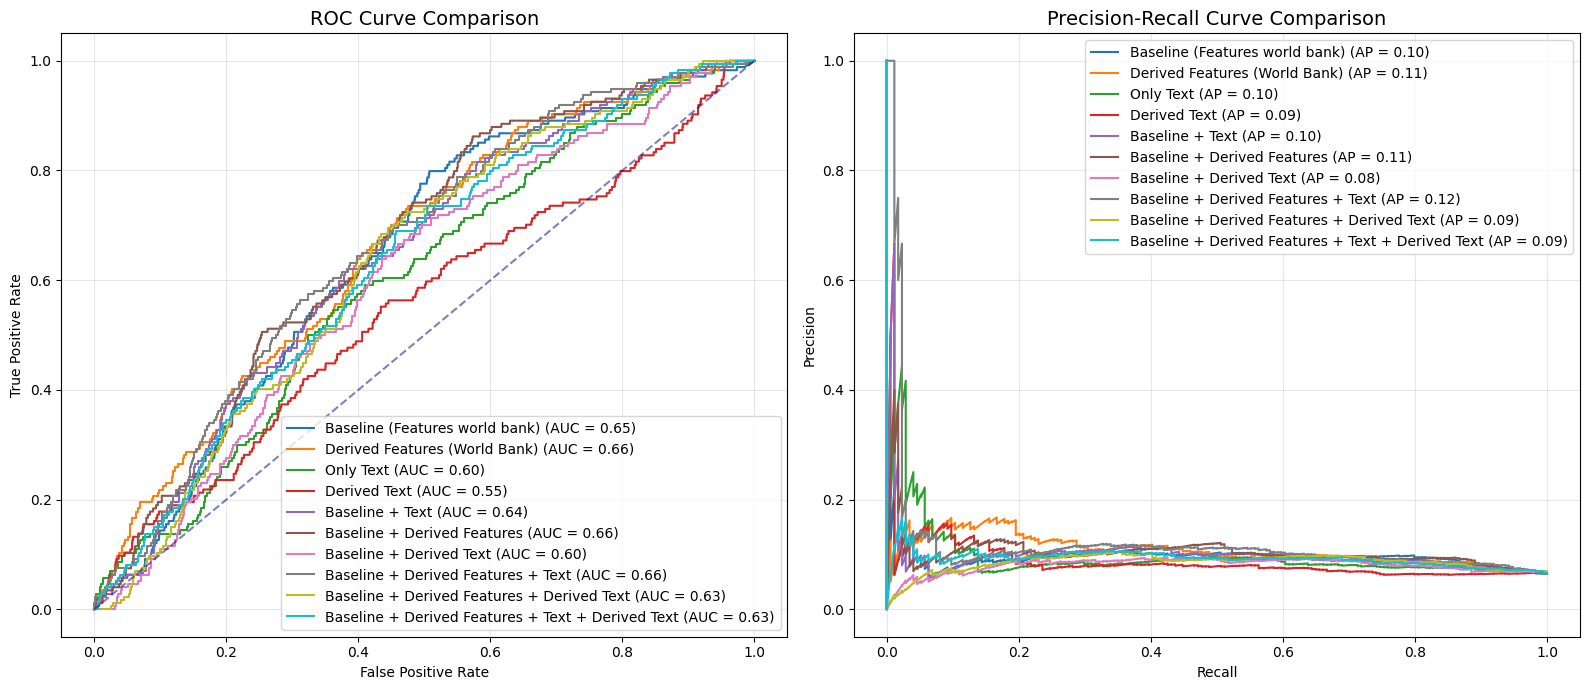

In [ ]:
# 1. DEFINE EXPERIMENT SETS
experiments = {
    # --- FINAL GROUPS ---
    "Baseline (Features world bank)": best_world_bank,
    "Derived Features (World Bank)": best_derived_wb,
    "Only Text": best_text,
    "Derived Text": best_derived_text,

    # --- COMBINED GROUPS ---
    "Baseline + Text": best_world_bank + best_text,
    "Baseline + Derived Features": best_world_bank + best_derived_wb,
    "Baseline + Derived Text": best_world_bank + best_derived_text,
    "Baseline + Derived Features + Text": best_world_bank + best_derived_wb + best_text,
    "Baseline + Derived Features + Derived Text": best_world_bank + best_derived_wb + best_derived_text,
    "Baseline + Derived Features + Text + Derived Text": best_world_bank + best_derived_wb + best_text + best_derived_text
}

# Containers for results
comparison_results = []

# Prepare the plot layout
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

for name, f_list in experiments.items():
    print(f"\n" + "="*60)
    print(f"RUNNING EXPERIMENT: {name}")
    print(f"Features count: {len(f_list)}")
    print("="*60)
    
    # 2. PREPARE DATA
    X, y = prepare_ml_experiment(final_dataset, features_to_use=f_list, target_col='target_4m')
    periods = X.index.get_level_values('month')

    # 3. DEFINE SPLIT STRATEGY
    panel_split = PanelSplit(
        periods=periods,
        n_splits=24,   
        test_size=1,
        gap=3        
    )

    # 4. INITIALIZE MODEL
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    all_y_true, all_y_pred, all_y_prob = [], [], []

    # 5. CROSS-VALIDATION LOOP (Moving Window)
    for train_idx, test_idx in panel_split.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        rf_model.fit(X_train, y_train)
        
        probs = rf_model.predict_proba(X_test)[:, 1]
        preds = rf_model.predict(X_test)
        
        all_y_true.extend(y_test.values)
        all_y_pred.extend(preds)
        all_y_prob.extend(probs)

    # 6. CALCULATE METRICS
    f1 = f1_score(all_y_true, all_y_pred)
    roc_auc = roc_auc_score(all_y_true, all_y_prob)
    avg_prec = average_precision_score(all_y_true, all_y_prob)
    
    comparison_results.append({
        'Experiment': name,
        'F1-Score': f1,
        'AUC-ROC': roc_auc,
        'Avg Precision': avg_prec,
        'Features': len(f_list)
    })

    # 7. PRINT ANALYSIS
    print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
    importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(importances.head(10))
    
    print(f"\nClassification Report ({name}):")
    print(classification_report(all_y_true, all_y_pred))

    # 8. ADD TO PLOTS
    # ROC Curve
    fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
    ax_pr.plot(recall, precision, label=f'{name} (AP = {avg_prec:.2f})')

# --- FINAL COMPARISON TABLE ---
df_results = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False)
print("\n" + "#"*40)
print("       FINAL RANKING")
print("#"*40)
print(df_results)

# --- VISUALIZATION FINISHING TOUCHES ---
ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
ax_roc.set_title('ROC Curve Comparison', fontsize=14)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14)
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()